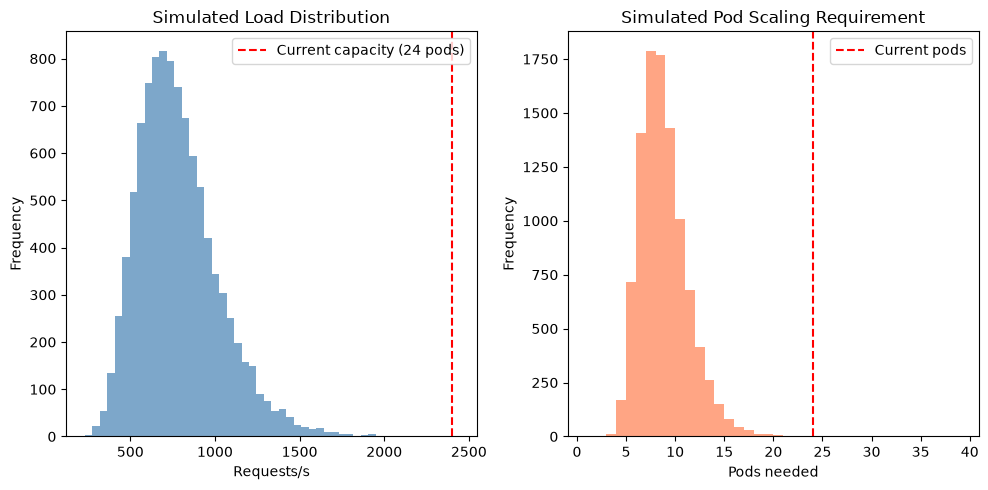

Median pods needed: 8
P95 pods needed: 13
P99 pods needed: 16
Current pods: 24
Recommended HPA max replicas: 16

Current capacity (24 pods) covers P99 scenarios.


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
n_simulations = 10000
n_pods_current = 24
requests_per_pod_capacity = 100  # max req/s per pod
mean_load = 250 * 3   # 750 req/s
std_load = 60 * 3

np.random.seed(42)
simulated_loads = np.random.lognormal(
    mean=np.log(mean_load), 
    sigma=0.3, 
    size=n_simulations
)

# How many pods are needed at a given load?
pods_needed = np.ceil(simulated_loads / requests_per_pod_capacity)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(simulated_loads, bins=50, color='steelblue', alpha=0.7)
plt.axvline(n_pods_current * requests_per_pod_capacity, color='red', 
            linestyle='--', label=f'Current capacity ({n_pods_current} pods)')
plt.xlabel('Requests/s')
plt.ylabel('Frequency')
plt.title('Simulated Load Distribution')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(pods_needed, bins=range(1, 40), color='coral', alpha=0.7)
plt.axvline(n_pods_current, color='red', linestyle='--', label='Current pods')
plt.xlabel('Pods needed')
plt.ylabel('Frequency')
plt.title('Simulated Pod Scaling Requirement')
plt.legend()

plt.tight_layout()
plt.show()

# Decision statistics
p50_pods = np.percentile(pods_needed, 50)
p95_pods = np.percentile(pods_needed, 95)
p99_pods = np.percentile(pods_needed, 99)

print(f"Median pods needed: {p50_pods:.0f}")
print(f"P95 pods needed: {p95_pods:.0f}")
print(f"P99 pods needed: {p99_pods:.0f}")
print(f"Current pods: {n_pods_current}")
print(f"Recommended HPA max replicas: {int(np.ceil(p99_pods))}")

if n_pods_current < p99_pods:
    print(f"\nWarning: current capacity ({n_pods_current} pods) may be INSUFFICIENT")
    print(f"    for {(p99_pods - n_pods_current):.0f} more pods needed at P99 load.")
else:
    print(f"\nCurrent capacity ({n_pods_current} pods) covers P99 scenarios.")